In [42]:
from __future__ import annotations

from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple, Literal

import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


GroupMode = Literal["sensors", "windows"]


# ----------------------------
# JSON helpers
# ----------------------------
def _load_json(path: str | Path) -> Dict[str, Any]:
    path = Path(path)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def _history_from_vectors_json(j: Dict[str, Any]) -> List[Dict[str, Any]]:
    n0_list = j.get("n0_value", None)
    sel_list = j.get("selection_vector", None)
    imp_list = j.get("importance_vector", None)

    if n0_list is None or sel_list is None or imp_list is None:
        raise KeyError("JSON must contain: n0_value, selection_vector, importance_vector")

    if len(n0_list) != len(sel_list) or len(n0_list) != len(imp_list):
        raise ValueError("Length mismatch among n0_value, selection_vector, importance_vector")

    out: List[Dict[str, Any]] = []
    for n0, s, im in zip(n0_list, sel_list, imp_list):
        out.append(
            {
                "n0_value": int(n0),
                "selection_vector": np.asarray(s, dtype=int),
                "importance_vector": np.asarray(im, dtype=float),
            }
        )

    # Sort by N0 ascending
    return sorted(out, key=lambda d: d["n0_value"], reverse=False)


def _align_by_n0(
    hist_a: List[Dict[str, Any]],
    hist_b: List[Dict[str, Any]],
) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]], List[int]]:
    map_a = {h["n0_value"]: h for h in hist_a}
    map_b = {h["n0_value"]: h for h in hist_b}
    common = sorted(set(map_a.keys()).intersection(map_b.keys()))
    if not common:
        raise ValueError("No common n0_value between histories.")
    return [map_a[n0] for n0 in common], [map_b[n0] for n0 in common], common


# ----------------------------
# FULL -> grouped + binned
# ----------------------------
def _full_group_active_per_iter(
    sel_flat_row: np.ndarray,
    M0: int,
    W0: int,
    group_mode: GroupMode,
) -> np.ndarray:
    """
    For one FULL iteration:
      - sensors: active if any window is active in that sensor row
      - windows: active if any sensor is active in that window col
    """
    sel_3d = sel_flat_row.reshape(M0, W0)
    if group_mode == "sensors":
        return (sel_3d > 0).any(axis=1).astype(float)  # (M0,)
    if group_mode == "windows":
        return (sel_3d > 0).any(axis=0).astype(float)  # (W0,)
    raise ValueError(f"Invalid group_mode={group_mode}")


def _full_group_importance_mean_per_iter(
    imp_flat_row: np.ndarray,
    M0: int,
    W0: int,
    group_mode: GroupMode,
) -> np.ndarray:
    """
    For one FULL iteration:
      - sensors: mean importance over windows for each sensor
      - windows: mean importance over sensors for each window
    """
    imp_3d = imp_flat_row.reshape(M0, W0)
    if group_mode == "sensors":
        return imp_3d.mean(axis=1).astype(float)  # (M0,)
    if group_mode == "windows":
        return imp_3d.mean(axis=0).astype(float)  # (W0,)
    raise ValueError(f"Invalid group_mode={group_mode}")


def _bin_full_history_to_n_groups(
    hist_full: List[Dict[str, Any]],
    M0: int,
    W0: int,
    group_mode: GroupMode,
) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    """
    Bins FULL iterations so number of rows == n_groups.
      - sensors: bin_size=W0  -> rows=M0
      - windows: bin_size=M0  -> rows=W0

    For each bin and each group:
      importance = mean_over_iters( mean_over_other_axis(importance) )
      alpha      = mean_over_iters( active_flag )
    """
    total_features = M0 * W0
    T = len(hist_full)
    if T != total_features:
        # Not necessarily fatal, but your FULL runs usually are exactly M0*W0 iterations.
        # We still bin using the chosen bin_size.
        pass

    if group_mode == "sensors":
        n_groups = M0
        bin_size = W0
        group_prefix = "s"
    else:
        n_groups = W0
        bin_size = M0
        group_prefix = "w"

    # Stack arrays
    sel_flat = np.vstack([h["selection_vector"].reshape(-1) for h in hist_full]).astype(int)
    imp_flat = np.vstack([h["importance_vector"].reshape(-1) for h in hist_full]).astype(float)

    if sel_flat.shape[1] != total_features or imp_flat.shape[1] != total_features:
        raise ValueError(f"FULL vectors must have length M0*W0={total_features}.")

    # Bin edges (use contiguous bins from the sorted history)
    bins: List[np.ndarray] = []
    idx = np.arange(sel_flat.shape[0])
    for start in range(0, len(idx), bin_size):
        bins.append(idx[start : start + bin_size])

    # If we got more bins than expected (e.g., incomplete run), truncate to n_groups.
    # If fewer bins, we still plot whatever exists, but it won't be “compatible”.
    if len(bins) >= n_groups:
        bins = bins[:n_groups]

    G = len(bins)
    imp_bin = np.zeros((G, n_groups), dtype=float)
    alpha_bin = np.zeros((G, n_groups), dtype=float)
    row_labels: List[str] = []

    for b, idc in enumerate(bins):
        # Aggregate presence and importance over iterations in this bin
        active_acc = np.zeros((n_groups,), dtype=float)
        imp_acc = np.zeros((n_groups,), dtype=float)

        for t in idc:
            active_acc += _full_group_active_per_iter(sel_flat[t], M0, W0, group_mode)
            imp_acc += _full_group_importance_mean_per_iter(imp_flat[t], M0, W0, group_mode)

        active_mean = active_acc / float(len(idc))
        imp_mean = imp_acc / float(len(idc))

        alpha_bin[b] = active_mean
        imp_bin[b] = imp_mean

        # Label by N0-range inside the bin (nice for reading)
        n0_vals = [hist_full[int(t)]["n0_value"] for t in idc]
        row_labels.append(f"N0 {int(min(n0_vals))}-{int(max(n0_vals))}")

    return imp_bin, alpha_bin, row_labels


# ----------------------------
# Time-TRUST grouped mats
# ----------------------------
def _group_mats_timetrust(
    hist_group: List[Dict[str, Any]],
    n_groups: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns:
      imp_mat: (T,n_groups)
      alpha:   (T,n_groups) = selection (0/1)
      ylabels: N0 labels (strings)
    """
    sel = np.vstack([h["selection_vector"].reshape(-1) for h in hist_group]).astype(int)
    imp = np.vstack([h["importance_vector"].reshape(-1) for h in hist_group]).astype(float)

    if sel.shape[1] != n_groups or imp.shape[1] != n_groups:
        raise ValueError(f"Time-TRUST vectors must have length {n_groups}.")

    alpha = sel.astype(float)
    ylabels = [f"N0={h['n0_value']}" for h in hist_group]
    return imp, alpha, ylabels


# ----------------------------
# Plot helper (RGBA with alpha)
# ----------------------------
def _imshow_with_alpha(
    ax: plt.Axes,
    values: np.ndarray,     # (T,G) importance
    alpha: np.ndarray,      # (T,G) in [0,1]
    cmap,
    norm: Normalize,
) -> None:
    """
    Draw an RGBA image where:
      color = cmap(norm(values))
      alpha = alpha (and also set to 0 if values is NaN)
    """
    vals = values.astype(float).copy()
    a = np.clip(alpha.astype(float).copy(), 0.0, 1.0)

    # mask NaNs -> white & invisible
    nan_mask = np.isnan(vals)
    vals[nan_mask] = 0.0
    a[nan_mask] = 0.0

    rgba = cmap(norm(vals))
    rgba[..., 3] = rgba[..., 3] * a

    ax.imshow(rgba, aspect="auto", interpolation="nearest")


from matplotlib.ticker import FixedLocator, FixedFormatter


from matplotlib.ticker import FixedLocator, FixedFormatter

def _nice_ticks(
    ax: plt.Axes,
    n: int,
    step: int,
    axis: str,
    labels: Sequence[str],
    fontsize: int,
) -> None:
    n = int(n)
    step = max(1, int(step))

    if len(labels) != n:
        raise ValueError(f"labels length ({len(labels)}) != n ({n})")

    idx = np.arange(n, dtype=int)
    ticks = idx[::step]
    tick_labels = [labels[i] for i in ticks]

    if axis == "x":
        ax.xaxis.set_major_locator(FixedLocator(ticks))
        ax.xaxis.set_major_formatter(FixedFormatter(tick_labels))
        ax.tick_params(axis="x", labelsize=fontsize, rotation=90)

    else:
        fs = max(4, fontsize - 1)
        ax.yaxis.set_major_locator(FixedLocator(ticks))
        ax.yaxis.set_major_formatter(FixedFormatter(tick_labels))

        # FORCE labels to show (important when sharey / gridspec hides them)
        ax.tick_params(axis="y", labelsize=fs, labelleft=True)
        for lab in ax.get_yticklabels():
            lab.set_visible(True)


# ----------------------------
# Public notebook functions
# ----------------------------
def plot_sensors_shutdown_full_vs_timetrust_ieee(
    *,
    full_json_path: str | Path,
    timetrust_sensors_json_path: str | Path,
    M0: int,
    W0: int,
    sensor_names: Optional[Sequence[str]] = None,
    figsize: Tuple[float, float] = (3.4, 5.4),
    x_tick_step: int = 1,
    y_tick_step_full: int = 1,
    y_tick_step_tt: int = 2,
    suptitle: str = "Shutdown heatmap (Sensors)",
    dataset: str = "DATASET",
    window_tag: str = "WINDOW_TAG",
    hidden_tag: str = "HIDDEN_TAG",
) -> None:
    hist_full = _history_from_vectors_json(_load_json(full_json_path))  # FULL has ~M0*W0 iters
    hist_tt = _history_from_vectors_json(_load_json(timetrust_sensors_json_path))  # TT has ~M0 iters

    # ✅ FULL binned independently: M0 groups of W0 iterations
    imp_full, alpha_full, y_full = _bin_full_history_to_n_groups(
        hist_full, M0=M0, W0=W0, group_mode="sensors"
    )

    # ✅ TT direct
    imp_tt, alpha_tt, y_tt = _group_mats_timetrust(hist_tt, n_groups=M0)

    # X labels
    if sensor_names is None:
        x_labels = [f"s{i}" for i in range(1, M0 + 1)]
    else:
        if len(sensor_names) != M0:
            raise ValueError(f"sensor_names length {len(sensor_names)} != M0={M0}")
        x_labels = list(sensor_names)

    cmap = plt.cm.viridis

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, hspace=0.34)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)

    v1 = imp_full[~np.isnan(imp_full)]
    norm1 = Normalize(vmin=float(np.min(v1)) if v1.size else 0.0, vmax=float(np.max(v1)) if v1.size else 1.0)
    _imshow_with_alpha(ax1, imp_full, alpha_full, cmap=cmap, norm=norm1)
    sm1 = ScalarMappable(norm=norm1, cmap=cmap)
    cbar1 = fig.colorbar(sm1, ax=ax1, fraction=0.04, pad=0.02)
    cbar1.ax.tick_params(labelsize=6)
    cbar1.set_label("Importance (TRUST, mean over windows)", fontsize=7)

    v2 = imp_tt[~np.isnan(imp_tt)]
    norm2 = Normalize(vmin=float(np.min(v2)) if v2.size else 0.0, vmax=float(np.max(v2)) if v2.size else 1.0)
    _imshow_with_alpha(ax2, imp_tt, alpha_tt, cmap=cmap, norm=norm2)
    sm2 = ScalarMappable(norm=norm2, cmap=cmap)
    cbar2 = fig.colorbar(sm2, ax=ax2, fraction=0.04, pad=0.02)
    cbar2.ax.tick_params(labelsize=6)
    cbar2.set_label("Importance (Time-TRUST sensors)", fontsize=7)

    ax1.set_title("TRUST (M0 bins of W0 iterations, alpha = presence %)", fontsize=8)
    ax2.set_title("Time-TRUST (alpha = active)", fontsize=8)

    _nice_ticks(ax1, len(x_labels), x_tick_step, "x", x_labels, fontsize=6)
    _nice_ticks(ax2, len(x_labels), x_tick_step, "x", x_labels, fontsize=6)
    _nice_ticks(ax1, len(y_full), y_tick_step_full, "y", y_full, fontsize=6)
    _nice_ticks(ax2, len(y_tt), y_tick_step_tt, "y", y_tt, fontsize=6)

    ax1.set_ylabel("TRUST bins", fontsize=7)
    ax2.set_ylabel("Iteration", fontsize=7)
    ax2.set_xlabel("Sensors", fontsize=7)

    fig.suptitle(
        f"{suptitle} | {dataset} | {window_tag} | {hidden_tag}",
        fontsize=8.5,
        y=0.995,
    )
    plt.tight_layout()
    plt.show()


def plot_windows_shutdown_full_vs_timetrust_ieee(
    *,
    full_json_path: str | Path,
    timetrust_windows_json_path: str | Path,
    M0: int,
    W0: int,
    window_labels: Optional[Sequence[str]] = None,
    figsize: Tuple[float, float] = (3.4, 5.4),
    x_tick_step: int = 1,
    y_tick_step_full: int = 1,
    y_tick_step_tt: int = 2,
    suptitle: str = "Shutdown heatmap (Windows)",
    dataset: str = "DATASET",
    window_tag: str = "WINDOW_TAG",
    hidden_tag: str = "HIDDEN_TAG",
) -> None:
    hist_full = _history_from_vectors_json(_load_json(full_json_path))  # FULL has ~M0*W0 iters
    hist_tt = _history_from_vectors_json(_load_json(timetrust_windows_json_path))  # TT has ~W0 iters

    # ✅ FULL binned independently: W0 groups of M0 iterations
    imp_full, alpha_full, y_full = _bin_full_history_to_n_groups(
        hist_full, M0=M0, W0=W0, group_mode="windows"
    )

    # ✅ TT direct
    imp_tt, alpha_tt, y_tt = _group_mats_timetrust(hist_tt, n_groups=W0)

    if window_labels is None:
        x_labels = [f"w{i}" for i in range(1, W0 + 1)]
    else:
        if len(window_labels) != W0:
            raise ValueError(f"window_labels length {len(window_labels)} != W0={W0}")
        x_labels = list(window_labels)

    cmap = plt.cm.viridis

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, hspace=0.34)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)

    v1 = imp_full[~np.isnan(imp_full)]
    norm1 = Normalize(vmin=float(np.min(v1)) if v1.size else 0.0, vmax=float(np.max(v1)) if v1.size else 1.0)
    _imshow_with_alpha(ax1, imp_full, alpha_full, cmap=cmap, norm=norm1)
    sm1 = ScalarMappable(norm=norm1, cmap=cmap)
    cbar1 = fig.colorbar(sm1, ax=ax1, fraction=0.04, pad=0.02)
    cbar1.ax.tick_params(labelsize=6)
    cbar1.set_label("Importance (TRUST, mean over sensors)", fontsize=7)

    v2 = imp_tt[~np.isnan(imp_tt)]
    norm2 = Normalize(vmin=float(np.min(v2)) if v2.size else 0.0, vmax=float(np.max(v2)) if v2.size else 1.0)
    _imshow_with_alpha(ax2, imp_tt, alpha_tt, cmap=cmap, norm=norm2)
    sm2 = ScalarMappable(norm=norm2, cmap=cmap)
    cbar2 = fig.colorbar(sm2, ax=ax2, fraction=0.04, pad=0.02)
    cbar2.ax.tick_params(labelsize=6)
    cbar2.set_label("Importance (Time-TRUST windows)", fontsize=7)

    ax1.set_title("TRUST (W0 bins of M0 iterations, alpha = presence %)", fontsize=8)
    ax2.set_title("Time-TRUST (alpha = active)", fontsize=8)

    _nice_ticks(ax1, len(x_labels), x_tick_step, "x", x_labels, fontsize=6)
    _nice_ticks(ax2, len(x_labels), x_tick_step, "x", x_labels, fontsize=6)
    _nice_ticks(ax1, len(y_full), y_tick_step_full, "y", y_full, fontsize=6)
    _nice_ticks(ax2, len(y_tt), y_tick_step_tt, "y", y_tt, fontsize=6)

    ax1.set_ylabel("TRUST bins", fontsize=7)
    ax2.set_ylabel("Iteration", fontsize=7)
    ax2.set_xlabel("Windows", fontsize=7)

    fig.suptitle(
        f"{suptitle} | {dataset} | {window_tag} | {hidden_tag}",
        fontsize=8.5,
        y=0.995,
    )
    plt.tight_layout()
    plt.show()


In [40]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any, Dict, Optional, Tuple, List


def _load_json(path: Path) -> Dict[str, Any]:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def _read_processed_metadata(
    processed_root: Path,
    dataset: str,
    window_tag: str,
) -> Tuple[int, int, List[str]]:
    """
    Returns:
      M0: int
      W0: int
      kept_sensors: list[str] (e.g., ["s2","s3",...])
    """
    meta_path = processed_root / dataset / window_tag / "metadata.json"
    if not meta_path.exists():
        raise FileNotFoundError(f"Missing metadata.json at: {meta_path}")

    meta = _load_json(meta_path)

    # Prefer structure block if present, else windowing shapes
    if "structure" in meta:
        M0 = int(meta["structure"]["n_sensors"])
        W0 = int(meta["structure"]["window_length"])
    else:
        # fallback
        M0 = int(meta["windowing"]["X_train_mw_shape"][1])
        W0 = int(meta["windowing"]["X_train_mw_shape"][2])

    kept_sensors = meta.get("features", {}).get("kept_sensors", None)
    if kept_sensors is None:
        # fallback: just s1..sM0
        kept_sensors = [f"s{i+1}" for i in range(M0)]
    else:
        kept_sensors = list(kept_sensors)

    # sanity
    if len(kept_sensors) != M0:
        raise ValueError(
            f"kept_sensors length mismatch: len={len(kept_sensors)} but M0={M0} "
            f"(meta_path={meta_path})"
        )

    return M0, W0, kept_sensors


def _build_vectors_paths(
    results_root: Path,
    dataset: str,
    window_tag: str,
    hidden_tag: str,
    slack: str = "0.000",
    exec_suffix: str = "mlp_rebuild__capped",
) -> Tuple[Path, Path, Path]:
    """
    Build canonical paths:
      full__<exec_suffix>_slackX/vectors_selection_importance.json
      sensors__<exec_suffix>_slackX/vectors_selection_importance.json
      windows__<exec_suffix>_slackX/vectors_selection_importance.json
    """
    base = results_root / dataset / window_tag / hidden_tag

    full_path = base / f"full__{exec_suffix}_slack{slack}" / "vectors_selection_importance.json"
    tt_sensors_path = base / f"sensors__{exec_suffix}_slack{slack}" / "vectors_selection_importance.json"
    tt_windows_path = base / f"windows__{exec_suffix}_slack{slack}" / "vectors_selection_importance.json"

    return full_path, tt_sensors_path, tt_windows_path


def plot_shutdown_full_vs_timetrust_from_metadata(
    dataset: str,
    window_tag: str,
    hidden_tag: str,
    *,
    processed_root: str | Path = "datasets/processed",
    results_root: str | Path = "results",
    slack: str = "0.000",
    exec_suffix: str = "mlp_rebuild__capped",
    figsize: Tuple[float, float] = (3.4, 5.2),
    x_tick_step: int = 1,
    y_tick_step_full: int = 1,
    y_tick_step_tt: int = 2,
) -> None:
    """
    Convenience wrapper that:
      - reads M0, W0, kept_sensors from processed metadata.json
      - builds full/sensors/windows vectors_selection_importance.json paths
      - calls both plotting functions
    """

    processed_root = Path(processed_root)
    results_root = Path(results_root)

    # 1) Read metadata => M0, W0, sensor labels
    M0, W0, kept_sensors = _read_processed_metadata(processed_root, dataset, window_tag)

    # 2) Build vector paths
    full_path, tt_sensors_path, tt_windows_path = _build_vectors_paths(
        results_root=results_root,
        dataset=dataset,
        window_tag=window_tag,
        hidden_tag=hidden_tag,
        slack=slack,
        exec_suffix=exec_suffix,
    )

    # 3) Existence checks (helpful error messages)
    for p in [full_path, tt_sensors_path, tt_windows_path]:
        if not p.exists():
            raise FileNotFoundError(f"Missing vectors JSON at: {p}")

    # 4) Call your plotting functions
    plot_sensors_shutdown_full_vs_timetrust_ieee(
        full_json_path=str(full_path),
        timetrust_sensors_json_path=str(tt_sensors_path),
        M0=M0,
        W0=W0,
        sensor_names=kept_sensors,  # <-- real sensor ids from metadata.json
        figsize=figsize,
        x_tick_step=x_tick_step,
        y_tick_step_full=y_tick_step_full,
        y_tick_step_tt=y_tick_step_tt,
        dataset=dataset,
        window_tag=window_tag,
        hidden_tag=hidden_tag,
    )

    plot_windows_shutdown_full_vs_timetrust_ieee(
        full_json_path=str(full_path),
        timetrust_windows_json_path=str(tt_windows_path),
        M0=M0,
        W0=W0,
        figsize=figsize,
        x_tick_step=x_tick_step,
        y_tick_step_full=y_tick_step_full,
        y_tick_step_tt=y_tick_step_tt,
        dataset=dataset,
        window_tag=window_tag,
        hidden_tag=hidden_tag,
    )


/tmp/ipykernel_3147000/3758197010.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


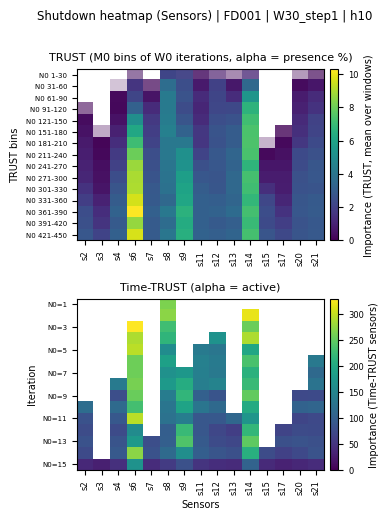

/tmp/ipykernel_3147000/3758197010.py:429: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


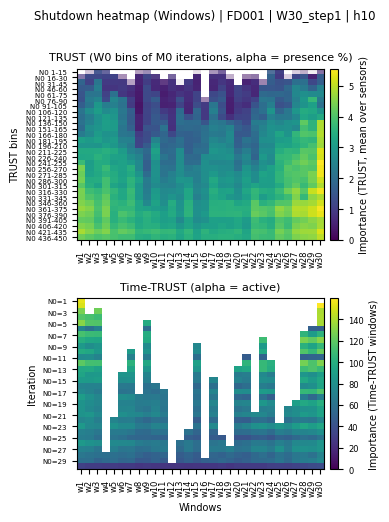

In [45]:
plot_shutdown_full_vs_timetrust_from_metadata(
    dataset="FD001",
    window_tag="W30_step1",
    hidden_tag="h10",
    figsize=(3.4, 5.2),
    x_tick_step=1,
    y_tick_step_full=1,
    y_tick_step_tt=2,
)

/tmp/ipykernel_3147000/3758197010.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


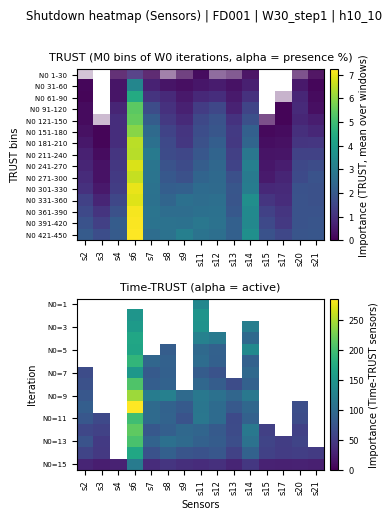

/tmp/ipykernel_3147000/3758197010.py:429: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


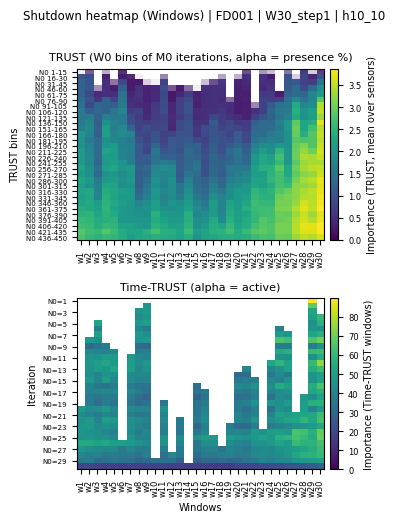

In [46]:
plot_shutdown_full_vs_timetrust_from_metadata(
    dataset="FD001",
    window_tag="W30_step1",
    hidden_tag="h10_10",
    figsize=(3.4, 5.2),
    x_tick_step=1,
    y_tick_step_full=1,
    y_tick_step_tt=2,
)